<a href="https://colab.research.google.com/github/fatima582/DI-BOOTCAMP/blob/main/Week2/Day5/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/US Superstore data (1).xls')

# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Display data types of each column
display(df.info())

# Check for missing values
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

None

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


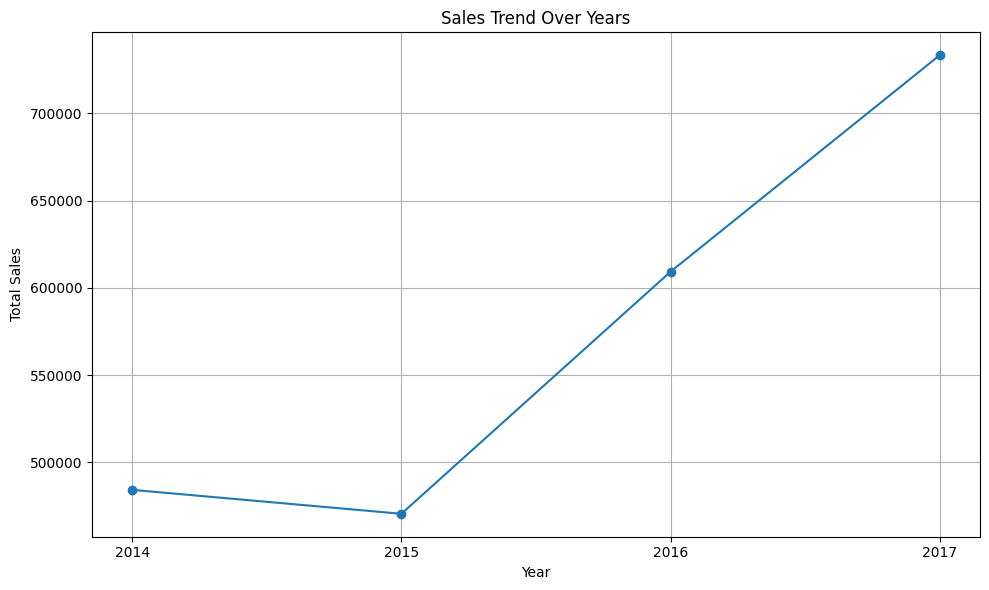

In [3]:
import matplotlib.pyplot as plt

# Extract year from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year

# Group by year and sum sales
sales_by_year = df.groupby('Order Year')['Sales'].sum().reset_index()

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(sales_by_year['Order Year'], sales_by_year['Sales'], marker='o', linestyle='-')
plt.title('Sales Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(sales_by_year['Order Year'])
plt.tight_layout()
plt.show()

In [4]:
# Check unique values in 'Country' column
unique_countries = df['Country'].unique()
print(f"Unique countries in the dataset: {list(unique_countries)}")

if len(unique_countries) == 1 and unique_countries[0] == 'United States':
    print("Since the dataset only contains data for 'United States', a map visualizing sales by country will not be very informative. Let's create an interactive map to visualize the distribution of sales by State instead.")
    # Group by State and sum sales
    sales_by_state = df.groupby('State')['Sales'].sum().reset_index()

    import plotly.express as px

    # Create a choropleth map for sales by state
    fig = px.choropleth(sales_by_state,
                        locations='State',
                        locationmode='USA-states',
                        color='Sales',
                        scope='usa',
                        color_continuous_scale="Viridis",
                        title='Sales Distribution by State in US Superstore')
    fig.show()
else:
    print("Proceeding with map visualization by country.")
    # Group by Country and sum sales
    sales_by_country = df.groupby('Country')['Sales'].sum().reset_index()

    import plotly.express as px

    # Create a choropleth map for sales by country
    fig = px.choropleth(sales_by_country,
                        locations='Country',
                        locationmode='country names',
                        color='Sales',
                        hover_name='Country',
                        color_continuous_scale="Viridis",
                        title='Sales Distribution by Country')
    fig.show()

Unique countries in the dataset: ['United States']
Since the dataset only contains data for 'United States', a map visualizing sales by country will not be very informative. Let's create an interactive map to visualize the distribution of sales by State instead.


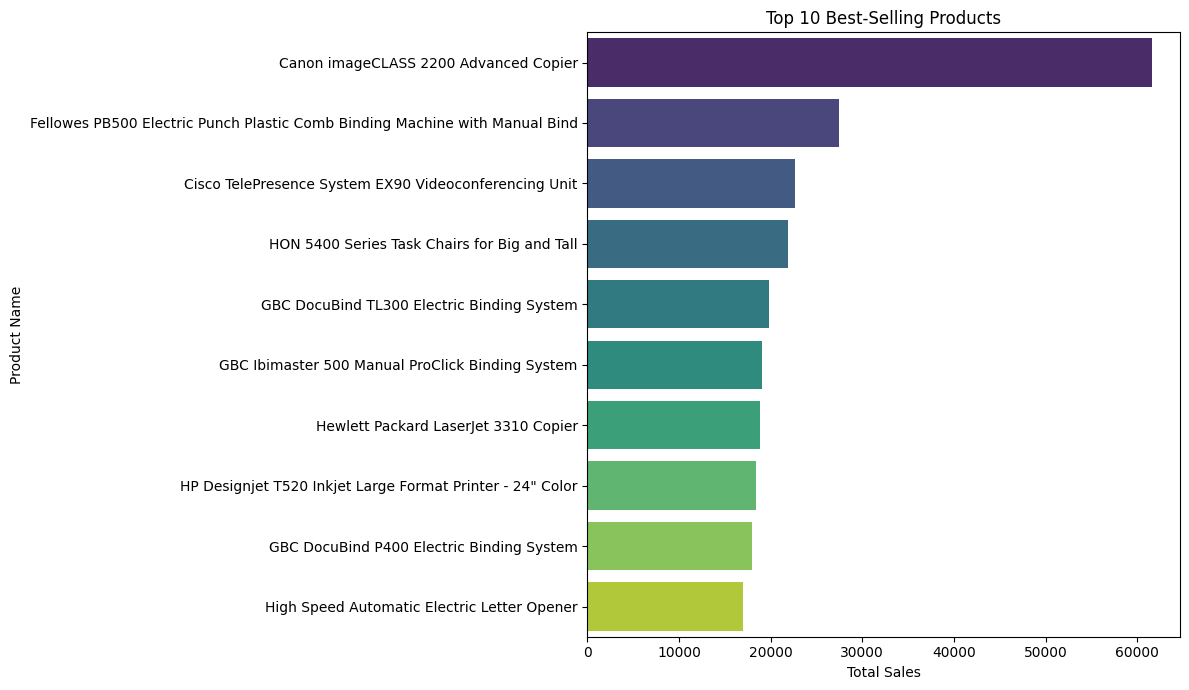

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by Product Name and sum sales, then get the top 10
top_10_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

# Create the bar chart using Seaborn
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales', y='Product Name', data=top_10_products, palette='viridis', hue='Product Name', legend=False)
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

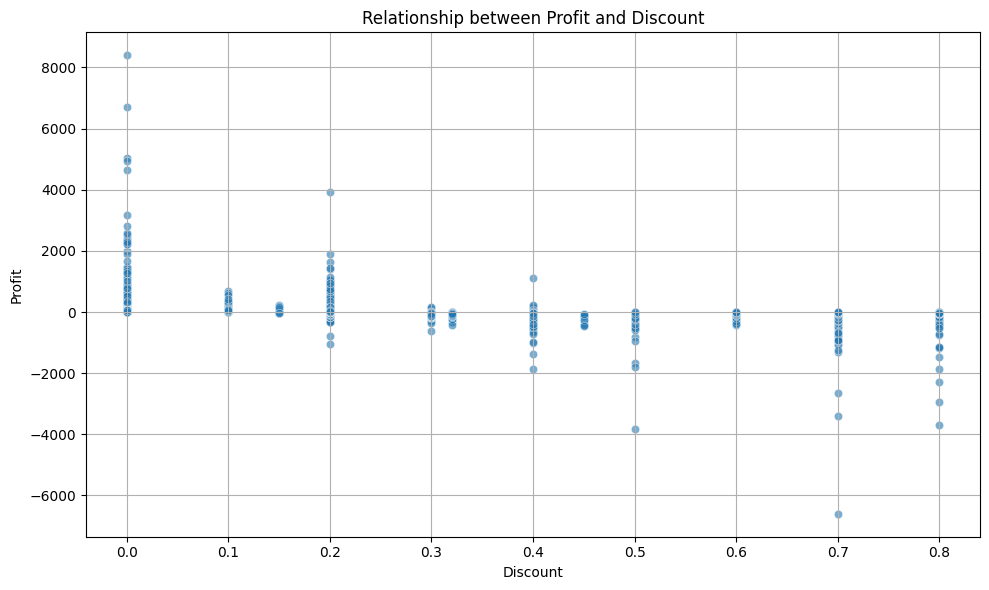

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot using Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Relationship between Profit and Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Analyse comparative et Observations

### Comparaison des informations obtenues

**Matplotlib (pour le graphique linéaire des tendances des ventes) :**
*   Le graphique linéaire des ventes par année a clairement montré une tendance à la hausse des ventes au fil des ans, avec une légère baisse en 2015 avant une forte croissance en 2016 et 2017. Cela met en évidence la performance globale de l'entreprise sur cette période.

**Plotly (pour la carte des ventes par État) :**
*   La carte choroplèthe par État (remplaçant la carte par pays puisque les données étaient uniquement pour les États-Unis) a permis de visualiser rapidement les régions où les ventes sont les plus élevées. Des États comme la Californie et New York se distinguent clairement par des volumes de ventes importants, tandis que d'autres États affichent des ventes plus faibles.

**Seaborn (pour le top 10 des produits et la relation profit/remise) :**
*   Le graphique à barres des 10 produits les plus vendus a identifié des articles spécifiques qui génèrent le plus de revenus, comme la "Canon imageCLASS 2200 Advanced Copier". Cette information est cruciale pour la gestion des stocks et les stratégies marketing.
*   Le nuage de points entre le profit et la remise a révélé une relation intéressante : des remises plus élevées ne mènent pas toujours à des profits plus faibles. En fait, il y a beaucoup de points où des remises importantes entraînent des pertes significatives, mais aussi des cas où des remises modérées ne compromettent pas le profit. Cela suggère que la stratégie de remise doit être affinée et ciblée, potentiellement par catégorie de produit ou par segment de clientèle.

### Facilité d'utilisation et efficacité des outils

**Matplotlib :**
*   **Facilité d'utilisation :** Matplotlib est très flexible et permet un contrôle très fin sur chaque élément du graphique. Cependant, cela peut aussi le rendre plus verbeux pour des visualisations simples. La création du graphique linéaire était relativement directe.
*   **Efficacité :** Excellent pour la personnalisation et les graphiques de base. Pour les graphiques interactifs ou très esthétiques sans beaucoup de code, il peut nécessiter des bibliothèques supplémentaires ou plus de travail manuel.

**Seaborn :**
*   **Facilité d'utilisation :** Seaborn est construit sur Matplotlib et offre une interface de haut niveau qui simplifie la création de visualisations statistiques complexes et esthétiques avec moins de code. La création du graphique à barres et du nuage de points était très intuitive.
*   **Efficacité :** Très efficace pour l'exploration de données et la création rapide de visualisations attrayantes. Il gère bien les DataFrames pandas, ce qui rend l'intégration transparente. Moins de contrôle granulaire que Matplotlib pur, mais suffisant pour la plupart des besoins statistiques.

**Plotly Express :**
*   **Facilité d'utilisation :** Plotly Express est extrêmement facile à utiliser pour créer des visualisations interactives avec une seule ligne de code. La création de la carte choroplèthe était très simple et le résultat est immédiatement interactif, ce qui est un avantage majeur.
*   **Efficacité :** Idéal pour les tableaux de bord et les rapports interactifs. L'interactivité intégrée (zoom, survol, sélection) améliore considérablement l'exploration des données, ce qui est très efficace pour communiquer des informations complexes.

**Conclusion :**
Pour cette analyse, **Seaborn** a été particulièrement efficace pour les visualisations statistiques grâce à sa simplicité et son esthétique par défaut. **Plotly Express** s'est avéré indispensable pour l'interactivité, notamment pour la carte. Matplotlib reste la base solide pour un contrôle total, mais pour des tâches d'exploration rapides et belles, Seaborn et Plotly sont souvent préférables.

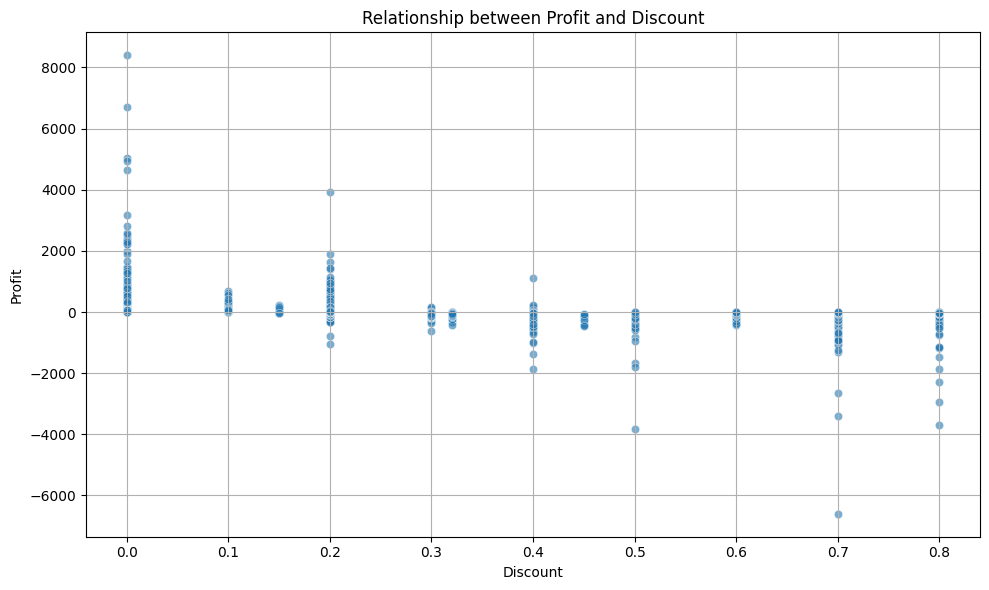

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot using Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Relationship between Profit and Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.tight_layout()
plt.show()